<a href="https://colab.research.google.com/github/sandeepkumarkusman/celebal-excellence-internship/blob/main/week4_sandeep_kumar_kusman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification: ANN vs CNN

In this notebook, we build image classification models on the **CIFAR-10 dataset** using two approaches:

1. **ANN (Artificial Neural Network)** — uses fully connected layers on flattened image vectors
2. **CNN (Convolutional Neural Network)** — uses convolution layers that preserve spatial information

We'll compare their accuracy, analyze learning curves, and explore how training strategies like data augmentation and early stopping affect results.

**CIFAR-10** contains 60,000 color images (32x32x3) split into 10 classes:
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

## Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


## Loading the Dataset

CIFAR-10 comes built into Keras — 50,000 training images and 10,000 test images.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)
print("Image dimensions:", x_train[0].shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4399s 26us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Image dimensions: (32, 32, 3)
Pixel value range: 0 - 255


## Visualizing Sample Images

Let's look at one sample from each class to get a sense of what the images look like.

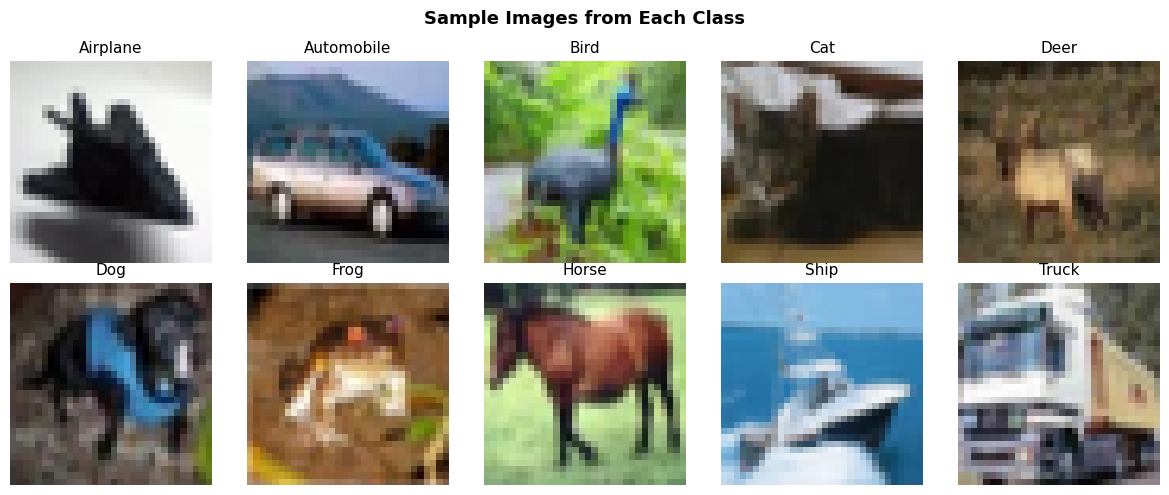

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx in range(10):
    img_idx = np.where(y_train.flatten() == class_idx)[0][0]
    ax = axes[class_idx // 5, class_idx % 5]
    ax.imshow(x_train[img_idx])
    ax.set_title(class_names[class_idx], fontsize=11)
    ax.axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

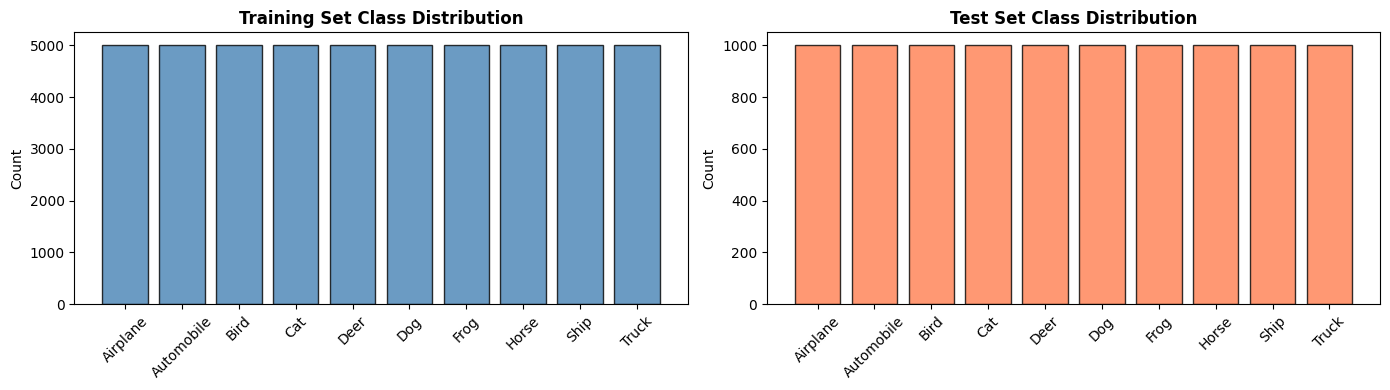

Each class has 5000 training and 1000 test images - dataset is balanced.


In [ ]:
# Check class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

unique_tr, counts_tr = np.unique(y_train, return_counts=True)
axes[0].bar(class_names, counts_tr, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Training Set Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

unique_te, counts_te = np.unique(y_test, return_counts=True)
axes[1].bar(class_names, counts_te, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Test Set Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Each class has {counts_tr[0]} training and {counts_te[0]} test images - dataset is balanced.")

## Data Preprocessing

We normalize pixel values from 0-255 to 0-1 range. This makes training more stable because the gradients won't be too large.

For ANN, we also flatten the images into 1D vectors (32x32x3 = 3072 values), since Dense layers expect flat input. CNN gets the original 3D shape.

In [ ]:
# Normalize to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten for ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized range:", x_train_norm.min(), "-", x_train_norm.max())
print("CNN input shape:", x_train_norm.shape)
print("ANN input shape:", x_train_flat.shape)

Normalized range: 0.0 - 1.0
CNN input shape: (50000, 32, 32, 3)
ANN input shape: (50000, 3072)


## ANN Model (Baseline)

The ANN takes flattened image vectors as input. It can't see the spatial arrangement of pixels — it treats each pixel value independently. This gives us a baseline to compare against the CNN.

Architecture: Dense(512) -> Dropout(0.3) -> Dense(256) -> Dropout(0.3) -> Dense(10, softmax)

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2514 - loss: 2.0345 - val_accuracy: 0.3156 - val_loss: 1.8885
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2926 - loss: 1.9138 - val_accuracy: 0.3444 - val_loss: 1.8255
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3026 - loss: 1.8829 - val_accuracy: 0.3584 - val_loss: 1.8205
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3176 - loss: 1.8587 - val_accuracy: 0.3540 - val_loss: 1.8061
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3221 - loss: 1.8396 - val_accuracy: 0.3664 - val_loss: 1.7856
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3276 - loss: 1.8306 - val_accuracy: 0.3372 - val_loss: 1.7886
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3354 - loss: 1.8198 - val_accuracy: 0.3778 - val_loss: 1.7560
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3389 - loss: 1.8078 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Loss: {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

ANN Test Loss: 1.7292
ANN Test Accuracy: 0.3872 (38.72%)


## CNN Model

Unlike the ANN, the CNN preserves the 2D spatial structure of images. It uses convolutional layers to detect local patterns (edges, textures, shapes) and pooling to reduce dimensions.

We use three conv blocks with increasing filter sizes (32, 64, 128) so that deeper layers can learn more complex features. BatchNormalization is used after each conv layer to stabilize training.

In [ ]:
cnn_model = models.Sequential([
    # Conv block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Dense classification head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4418 - loss: 1.5720 - val_accuracy: 0.5606 - val_loss: 1.2447
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5973 - loss: 1.1424 - val_accuracy: 0.5010 - val_loss: 1.5050
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6681 - loss: 0.9547 - val_accuracy: 0.6398 - val_loss: 1.0955
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7179 - loss: 0.8074 - val_accuracy: 0.6958 - val_loss: 0.9092
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7523 - loss: 0.7076 - val_accuracy: 0.7396 - val_loss: 0.7641
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7812 - loss: 0.6193 - val_accuracy: 0.7306 - val_loss: 0.7776
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8109 - loss: 0.5389 - val_accuracy: 0.7340 - val_loss: 0.8319
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8360 - loss: 0.4644 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")
print(f"\nCNN outperforms ANN by {(cnn_test_acc - ann_test_acc)*100:.2f} percentage points")

CNN Test Loss: 0.9058
CNN Test Accuracy: 0.7339 (73.39%)

CNN outperforms ANN by 34.67 percentage points


## Comparing ANN vs CNN Learning Curves

Plotting the validation accuracy and loss for both models over the 10 training epochs.

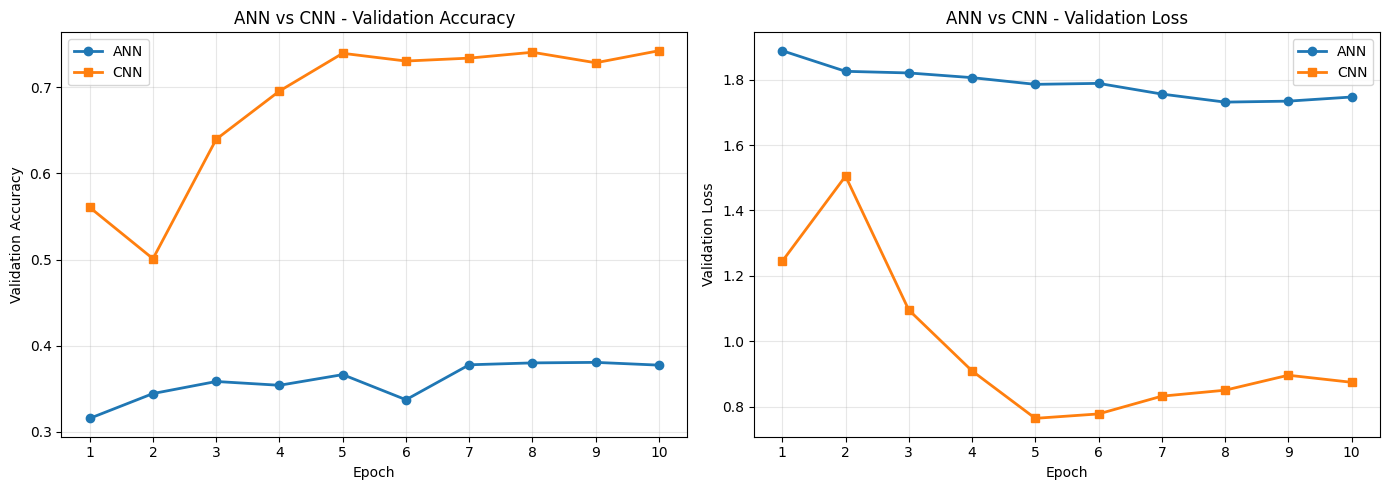

ANN final val accuracy: 0.3774
CNN final val accuracy: 0.7426


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, 11)

# Validation Accuracy
axes[0].plot(epochs_range, ann_history.history['val_accuracy'], 'o-', label='ANN', linewidth=2)
axes[0].plot(epochs_range, cnn_history.history['val_accuracy'], 's-', label='CNN', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('ANN vs CNN - Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

# Validation Loss
axes[1].plot(epochs_range, ann_history.history['val_loss'], 'o-', label='ANN', linewidth=2)
axes[1].plot(epochs_range, cnn_history.history['val_loss'], 's-', label='CNN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('ANN vs CNN - Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()

print(f"ANN final val accuracy: {ann_history.history['val_accuracy'][-1]:.4f}")
print(f"CNN final val accuracy: {cnn_history.history['val_accuracy'][-1]:.4f}")

## CNN Per-Class Analysis

Let's look at how the CNN performs on each individual class using a confusion matrix and classification report.

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.71      0.83      0.76      1000
  Automobile       0.87      0.85      0.86      1000
        Bird       0.68      0.61      0.64      1000
         Cat       0.57      0.49      0.53      1000
        Deer       0.67      0.72      0.69      1000
         Dog       0.68      0.60      0.64      1000
        Frog       0.63      0.91      0.75      1000
       Horse       0.87      0.72      0.78      1000
        Ship       0.86      0.83      0.84      1000
       Truck       0.86      0.79      0.83      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



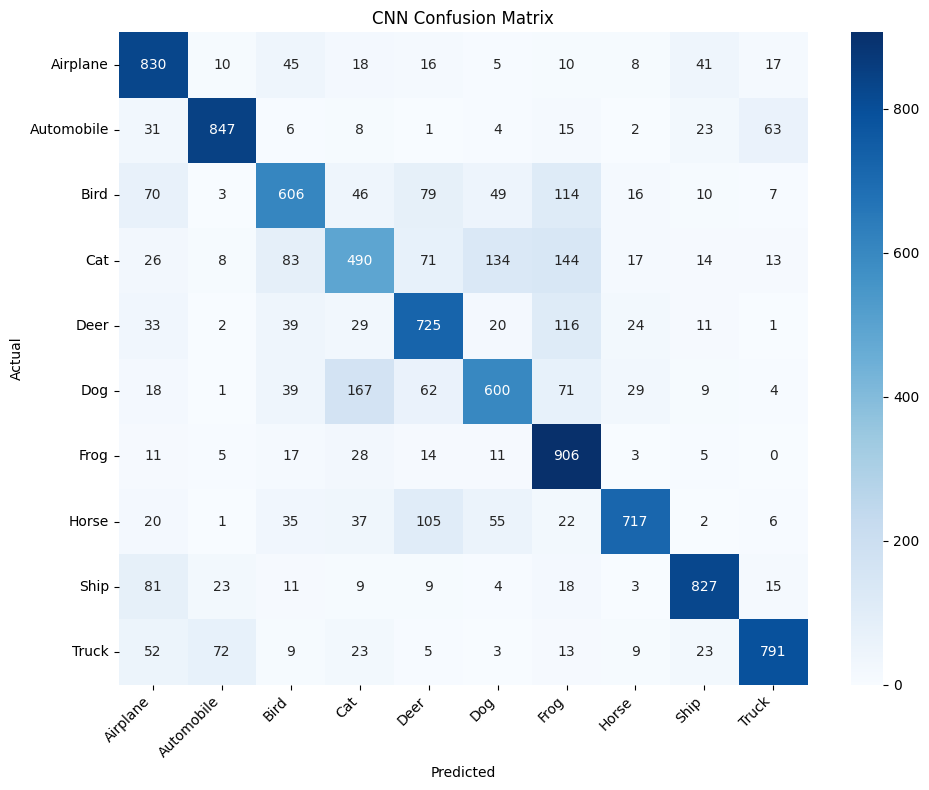

In [ ]:
y_pred = np.argmax(cnn_model.predict(x_test_norm, verbose=0), axis=1)
y_true = y_test.flatten()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Augmentation

Data augmentation helps improve generalization by applying random transformations to training images — the model sees slightly different versions each epoch, which reduces overfitting.

We use RandomFlip, RandomRotation, and RandomZoom layers that are only active during training. During evaluation, images pass through unchanged.

In [ ]:
aug_cnn_model = models.Sequential([
    # Augmentation layers (only active during training)
    layers.RandomFlip('horizontal', input_shape=(32, 32, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Same conv architecture as before
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3566 - loss: 1.7749 - val_accuracy: 0.3644 - val_loss: 1.7576
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4645 - loss: 1.4913 - val_accuracy: 0.5112 - val_loss: 1.4016
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5206 - loss: 1.3480 - val_accuracy: 0.5604 - val_loss: 1.2851
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5657 - loss: 1.2361 - val_accuracy: 0.5932 - val_loss: 1.1862
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5919 - loss: 1.1726 - val_accuracy: 0.5802 - val_loss: 1.1780
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6114 - loss: 1.1181 - val_accuracy: 0.6754 - val_loss: 0.9762
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6318 - loss: 1.0676 - val_accuracy: 0.6320 - val_loss: 1.1287
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6475 - loss: 1.0207 - val_ac

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Loss: {aug_test_loss:.4f}")
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Augmented CNN Test Loss: 1.0468
Augmented CNN Test Accuracy: 0.6616 (66.16%)


## Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['ANN', 'CNN (32-64-128)', 'CNN + Augmentation'],
    'Test Accuracy': [round(ann_test_acc, 4), round(cnn_test_acc, 4), round(aug_test_acc, 4)],
    'Test Loss': [round(ann_test_loss, 4), round(cnn_test_loss, 4), round(aug_test_loss, 4)]
})
comparison_df.index += 1
comparison_df

,Model,Test Accuracy,Test Loss
1,ANN,0.3872,1.7292
2,CNN (32-64-128),0.7339,0.9058
3,CNN + Augmentation,0.6616,1.0468


---

# Student Tasks

Below are the 5 tasks completed as part of this assignment.

### Task 1: Increase ANN Dense Layers

Adding more hidden layers (512 -> 256 -> 128 -> 64) to see if a deeper ANN can learn better from flat image vectors.

In [ ]:
deeper_ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deeper_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_ann.summary()

deeper_ann_history = deeper_ann.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deeper_ann_loss, deeper_ann_acc = deeper_ann.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nBaseline ANN accuracy: {ann_test_acc:.4f}")
print(f"Deeper ANN accuracy:   {deeper_ann_acc:.4f}")
print(f"Difference: {(deeper_ann_acc - ann_test_acc)*100:+.2f}%")
print("\nAdding more layers gives only a small improvement since ANN still can't capture spatial patterns.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,746,506 (6.66 MB)

 Trainable params: 1,746,506 (6.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2189 - loss: 2.0777 - val_accuracy: 0.3022 - val_loss: 1.9032
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2860 - loss: 1.9308 - val_accuracy: 0.3156 - val_loss: 1.8847
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3047 - loss: 1.8863 - val_accuracy: 0.3434 - val_loss: 1.8223
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3107 - loss: 1.8682 - val_accuracy: 0.3418 - val_loss: 1.8228
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3243 - loss: 1.8440 - val_accuracy: 0.3644 - val_loss: 1.7827
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3332 - loss: 1.8250 - val_accuracy: 0.3748 - val_loss: 1.7769
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3408 - loss: 1.8083 - val_accuracy: 0.3910 - val_loss: 1.7578
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3430 - loss: 1.8023 - val_accuracy: 0

### Task 2: Scale CNN Filter Sizes (32 -> 64 -> 128)

Our main CNN already uses the 32-64-128 filter pattern. To show why this matters, let's compare it against a CNN that uses only 32 filters throughout.

In [ ]:
# CNN with uniform 32 filters for comparison
small_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

small_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Small CNN (32-32-32) params: {small_cnn.count_params():,}")
print(f"Scaled CNN (32-64-128) params: {cnn_model.count_params():,}")

small_cnn_history = small_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

small_cnn_loss, small_cnn_acc = small_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nSmall CNN (32-32-32) accuracy:  {small_cnn_acc:.4f}")
print(f"Scaled CNN (32-64-128) accuracy: {cnn_test_acc:.4f}")
print(f"Scaling filters improved accuracy by {(cnn_test_acc - small_cnn_acc)*100:.2f} percentage points.")

Small CNN (32-32-32) params: 283,338
Scaled CNN (32-64-128) params: 1,144,138
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4740 - loss: 1.4786 - val_accuracy: 0.4226 - val_loss: 1.9040
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6134 - loss: 1.1024 - val_accuracy: 0.6298 - val_loss: 1.0586
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6700 - loss: 0.9385 - val_accuracy: 0.6254 - val_loss: 1.0900
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7048 - loss: 0.8395 - val_accuracy: 0.6500 - val_loss: 0.9866
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7329 - loss: 0.7531 - val_accuracy: 0.6760 - val_loss: 0.9880
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7571 - loss: 0.6922 - val_accuracy: 0.7222 - val_loss: 0.8149
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7772 - loss: 0.6286 - val_accuracy: 0.7202 - val_loss: 0.8426
Epoch 8/10
704/704 ━━━━━

### Task 3: Increase Training to 20 Epochs

Training for longer to see if accuracy keeps improving or if the model starts overfitting.

In [ ]:
# Fresh CNN trained for 20 epochs
cnn_20 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20_history = cnn_20.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20_loss, cnn_20_acc = cnn_20.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN 10 epochs accuracy: {cnn_test_acc:.4f}")
print(f"CNN 20 epochs accuracy: {cnn_20_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4455 - loss: 1.5627 - val_accuracy: 0.5642 - val_loss: 1.2286
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6069 - loss: 1.1285 - val_accuracy: 0.6262 - val_loss: 1.0561
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6763 - loss: 0.9306 - val_accuracy: 0.5946 - val_loss: 1.2105
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7214 - loss: 0.7990 - val_accuracy: 0.6382 - val_loss: 1.1317
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7567 - loss: 0.6857 - val_accuracy: 0.6956 - val_loss: 0.8917
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7896 - loss: 0.6011 - val_accuracy: 0.6272 - val_loss: 1.3360
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8199 - loss: 0.5117 - val_accuracy: 0.7132 - val_loss: 0.8941
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8401 - loss: 0.4550 - val_accuracy: 

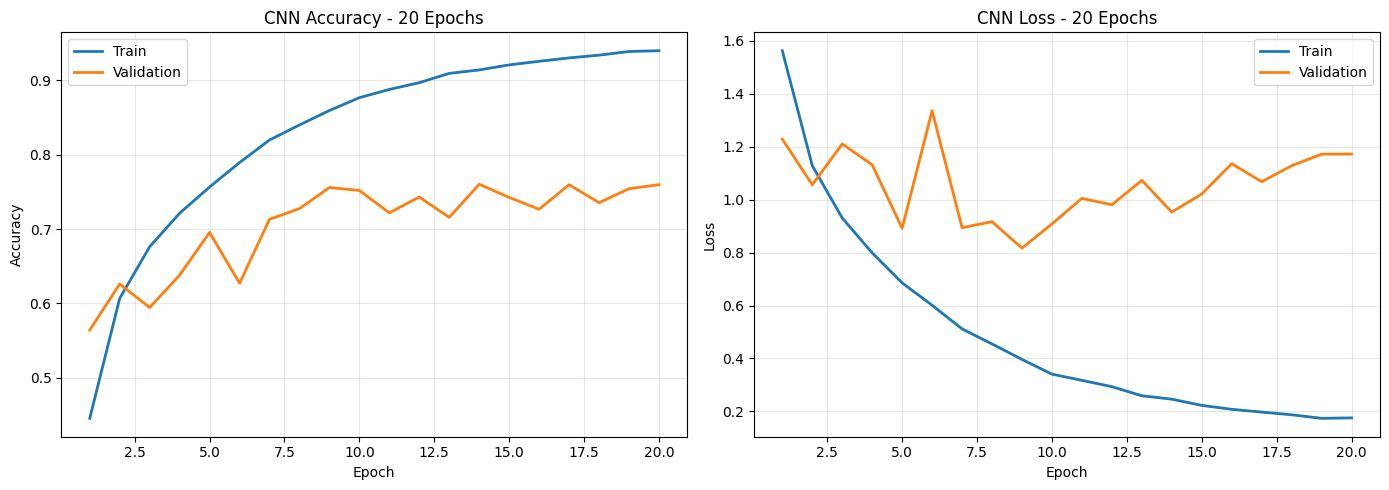

After around 10-12 epochs, the training accuracy keeps going up but validation
accuracy plateaus — this is a sign of overfitting. EarlyStopping can help with this.


In [ ]:
# Plotting the 20-epoch training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_20 = range(1, 21)

axes[0].plot(epochs_20, cnn_20_history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(epochs_20, cnn_20_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('CNN Accuracy - 20 Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_20, cnn_20_history.history['loss'], label='Train', linewidth=2)
axes[1].plot(epochs_20, cnn_20_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('CNN Loss - 20 Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("After around 10-12 epochs, the training accuracy keeps going up but validation")
print("accuracy plateaus — this is a sign of overfitting. EarlyStopping can help with this.")

### Task 4: Add EarlyStopping

EarlyStopping monitors the validation loss and stops training when it stops improving. We set `patience=3` (wait 3 epochs before stopping) and `restore_best_weights=True` so the model reverts to its best state.

In [ ]:
cnn_es = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

es_loss, es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
actual_epochs = len(es_history.history['loss'])

print(f"\nTraining stopped at epoch {actual_epochs} out of 20")
print(f"Accuracy with EarlyStopping: {es_acc:.4f}")
print(f"Accuracy without (20 epochs): {cnn_20_acc:.4f}")
print(f"Saved {20 - actual_epochs} epochs of unnecessary training")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4548 - loss: 1.5530 - val_accuracy: 0.5318 - val_loss: 1.3092
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5936 - loss: 1.1569 - val_accuracy: 0.5884 - val_loss: 1.1825
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6677 - loss: 0.9520 - val_accuracy: 0.6194 - val_loss: 1.1069
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7139 - loss: 0.8172 - val_accuracy: 0.7054 - val_loss: 0.8486
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7528 - loss: 0.7069 - val_accuracy: 0.7100 - val_loss: 0.8679
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7820 - loss: 0.6200 - val_accuracy: 0.6986 - val_loss: 0.9095
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8144 - loss: 0.5347 - val_accuracy: 0.7298 - val_loss: 0.8396
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8332 - loss: 0.4727 - val_accuracy: 

### Task 5: Data Augmentation Training

We already trained the augmented CNN above. Here we compare its training curve against the standard CNN to see how augmentation affects the learning process.

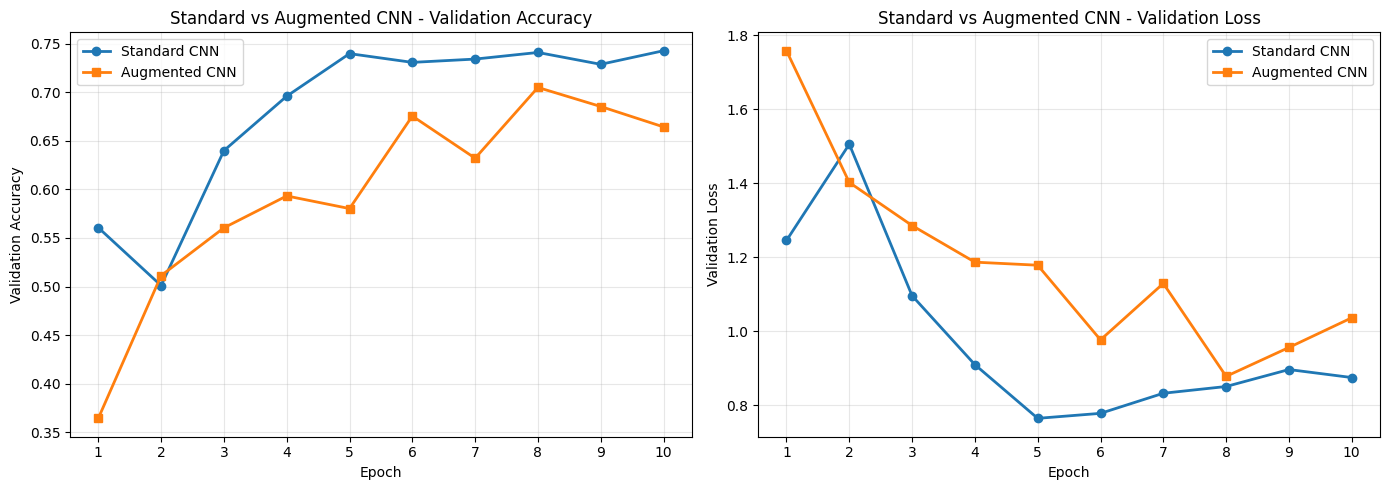

Standard CNN accuracy:  0.7339
Augmented CNN accuracy: 0.6616

Augmentation makes training harder (model sees varied data each time),
so it may not always show higher accuracy in just 10 epochs.
But it helps reduce overfitting with longer training.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_10 = range(1, 11)

# Validation accuracy
axes[0].plot(epochs_10, cnn_history.history['val_accuracy'], 'o-', label='Standard CNN', linewidth=2)
axes[0].plot(epochs_10, aug_history.history['val_accuracy'], 's-', label='Augmented CNN', linewidth=2)
axes[0].set_title('Standard vs Augmented CNN - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_10)

# Validation loss
axes[1].plot(epochs_10, cnn_history.history['val_loss'], 'o-', label='Standard CNN', linewidth=2)
axes[1].plot(epochs_10, aug_history.history['val_loss'], 's-', label='Augmented CNN', linewidth=2)
axes[1].set_title('Standard vs Augmented CNN - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_10)

plt.tight_layout()
plt.show()

print(f"Standard CNN accuracy:  {cnn_test_acc:.4f}")
print(f"Augmented CNN accuracy: {aug_test_acc:.4f}")
print("\nAugmentation makes training harder (model sees varied data each time),")
print("so it may not always show higher accuracy in just 10 epochs.")
print("But it helps reduce overfitting with longer training.")

---

## Final Comparison - All Models

In [ ]:
all_results = pd.DataFrame({
    'Model': [
        'ANN Baseline',
        'Deeper ANN (4 layers)',
        'Small CNN (32-32-32)',
        'CNN (32-64-128)',
        'CNN + Augmentation',
        'CNN (20 Epochs)',
        'CNN + EarlyStopping'
    ],
    'Test Accuracy': [
        round(ann_test_acc, 4),
        round(deeper_ann_acc, 4),
        round(small_cnn_acc, 4),
        round(cnn_test_acc, 4),
        round(aug_test_acc, 4),
        round(cnn_20_acc, 4),
        round(es_acc, 4)
    ],
    'Epochs': [10, 10, 10, 10, 10, 20, actual_epochs]
})

all_results = all_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
all_results.index += 1
all_results.index.name = 'Rank'
all_results

,Model,Test Accuracy,Epochs
Rank,,,
1,CNN (20 Epochs),0.7416,20
2,CNN (32-64-128),0.7339,10
3,Small CNN (32-32-32),0.7312,10
4,CNN + EarlyStopping,0.7101,10
5,CNN + Augmentation,0.6616,10
6,Deeper ANN (4 layers),0.3930,10
7,ANN Baseline,0.3872,10


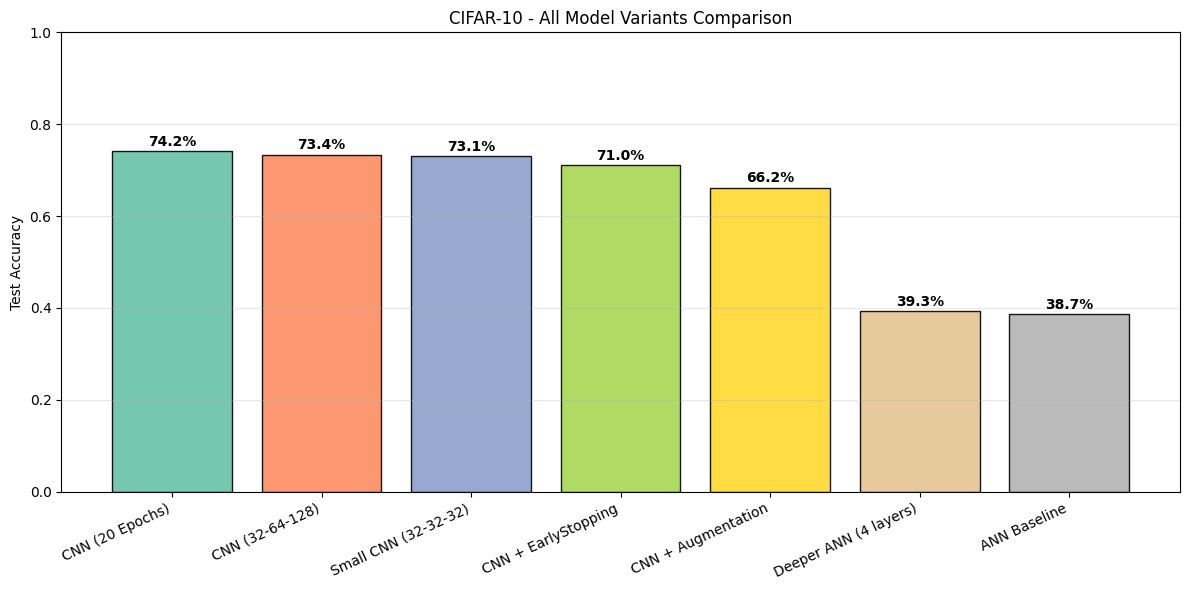

In [ ]:
plt.figure(figsize=(12, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(all_results)))
bars = plt.bar(all_results['Model'], all_results['Test Accuracy'],
               color=colors, edgecolor='black', alpha=0.9)

for bar, acc in zip(bars, all_results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.ylabel('Test Accuracy')
plt.title('CIFAR-10 - All Model Variants Comparison')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

From the experiments above, a few things are clear:

**ANN vs CNN:** The CNN beats the ANN by a large margin on CIFAR-10. This makes sense because images have spatial structure (edges, textures, shapes), and CNNs can capture that through convolution while ANNs just see a flat list of numbers. Even adding more Dense layers to the ANN (Task 1) didn't help much.

**Architecture matters:** Scaling filter sizes from 32 to 64 to 128 (Task 2) gave a noticeable accuracy boost. Deeper layers need more filters to represent the more abstract features they learn.

**Training strategy matters too:** Training longer (Task 3) showed signs of overfitting — the training accuracy kept climbing but validation accuracy stopped improving. EarlyStopping (Task 4) helped prevent this by cutting off training at the right point. Data augmentation (Task 5) is another useful technique that makes the model more robust by showing it varied versions of the training images.

Overall, a well-designed CNN with BatchNormalization, Dropout, and smart training strategies gives the best results on image classification tasks like CIFAR-10.